In [ ]:


# 1. Import all libraries at once
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
import itertools
from zipfile import ZipFile
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

In [ ]:
# 2. Download and extract dataset (only run once if needed)
!pip install kaggle -q
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Only download if not already present
if not os.path.exists('/content/forest-fire-smoke-and-non-fire-image-dataset.zip'):
    !kaggle datasets download -d amerzishminha/forest-fire-smoke-and-non-fire-image-dataset -q

if not os.path.exists('/content/FOREST_FIRE_SMOKE_AND_NON_FIRE_DATASET'):
    with ZipFile('/content/forest-fire-smoke-and-non-fire-image-dataset.zip', 'r') as zip_ref:
        zip_ref.extractall()
    print('Dataset extracted successfully')
else:
    print('Dataset already exists')

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/amerzishminha/forest-fire-smoke-and-non-fire-image-dataset
License(s): CC0-1.0
Dataset extracted successfully


In [ ]:
# 3. Configuration and constants
IMG_SIZE = 64  # Keeping original size for faster training
BATCH_SIZE = 32
EPOCHS = 30
NUM_CLASSES = 3
DATA_DIR = '/content/FOREST_FIRE_SMOKE_AND_NON_FIRE_DATASET'

# Verify dataset structure
print("Checking dataset structure...")
for split in ['train', 'test']:
    path = f'{DATA_DIR}/{split}'
    if os.path.exists(path):
        classes = os.listdir(path)
        total_images = sum([len(os.listdir(f'{path}/{cls}')) for cls in classes])
        print(f"{split}: {len(classes)} classes, {total_images} images")
        print(f"Classes: {classes}")

Checking dataset structure...
train: 3 classes, 32400 images
Classes: ['fire', 'Smoke', 'non fire']
test: 3 classes, 10500 images
Classes: ['fire', 'Smoke', 'non fire']


In [ ]:
# 4. Data generators - Train with augmentation, Test without (for validation)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

# Test/Validation data - only rescaling
test_datagen = ImageDataGenerator(rescale=1./255)

# Training set - from train folder only
training_set = train_datagen.flow_from_directory(
    f'{DATA_DIR}/train',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

# Validation set - from test folder (used during training)
validation_set = test_datagen.flow_from_directory(
    f'{DATA_DIR}/test',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False  # Keep order for consistent evaluation
)

# Final evaluation also uses the test set
testing_set = test_datagen.flow_from_directory(
    f'{DATA_DIR}/test',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False  # Important: Don't shuffle for evaluation
)

# Get class indices
class_indices = training_set.class_indices
class_names = {v: k for k, v in class_indices.items()}
print(f"\nClass mapping: {class_names}")

Found 32398 images belonging to 3 classes.
Found 10500 images belonging to 3 classes.
Found 10500 images belonging to 3 classes.

Class mapping: {0: 'Smoke', 1: 'fire', 2: 'non fire'}


In [ ]:
# 5. Improved CNN architecture
def create_model(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    model = Sequential([
        # First convolutional block
        Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        BatchNormalization(),
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        # Second convolutional block
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        # Third convolutional block
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        # Dense layers
        Flatten(),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])

    return model

# Create and compile the model
cnn = create_model()
optimizer = Adam(learning_rate=0.001)
cnn.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 2,421,027 (9.24 MB)

 Trainable params: 2,419,363 (9.23 MB)

 Non-trainable params: 1,664 (6.50 KB)

In [ ]:
# 6. Callbacks for better training
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=4,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        'best_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

In [ ]:
# 7. Train the model
print("Starting training...")
print(f"Training samples: {training_set.samples}")
print(f"Validation samples (from test folder): {validation_set.samples}")
print(f"Test samples: {testing_set.samples}")

history = cnn.fit(
    training_set,
    validation_data=validation_set,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Starting training...
Training samples: 32398
Validation samples (from test folder): 10500
Test samples: 10500
Epoch 1/30
  90/1013 ━━━━━━━━━━━━━━━━━━━━ 16:38 1s/step - accuracy: 0.6656 - loss: 0.9516 - precision: 0.6785 - recall: 0.6433

KeyboardInterrupt: 

Starting training...
Training samples: 32398
Validation samples (from test folder): 10500
Test samples: 10500
Epoch 1/30
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - accuracy: 0.8050 - loss: 0.5660 - precision: 0.8213 - recall: 0.7907
Epoch 1: val_accuracy improved from None to 0.88505, saving model to best_model.h5
WARNING:absl:You are saving your model as an HDF5 file via `model.save()` or `keras.saving.save_model(model)`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')` or `keras.saving.save_model(model, 'my_model.keras')`. 

Epoch 1: finished saving model to best_model.h5
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 381s 360ms/step - accuracy: 0.8522 - loss: 0.4223 - precision: 0.8661 - recall: 0.8394 - val_accuracy: 0.8850 - val_loss: 0.3056 - val_precision: 0.8960 - val_recall: 0.8755 - learning_rate: 0.0010
Epoch 2/30
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 0.9018 - loss: 0.2763 - precision: 0.9114 - recall: 0.8926
Epoch 2: val_accuracy improved from 0.88505 to 0.90733, saving model to best_model.h5
WARNING:absl:You are saving your model as an HDF5 file via `model.save()` or `keras.saving.save_model(model)`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')` or `keras.saving.save_model(model, 'my_model.keras')`. 

Epoch 2: finished saving model to best_model.h5
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 344s 339ms/step - accuracy: 0.9062 - loss: 0.2671 - precision: 0.9146 - recall: 0.8985 - val_accuracy: 0.9073 - val_loss: 0.2828 - val_precision: 0.9116 - val_recall: 0.9043 - learning_rate: 0.0010
Epoch 3/30
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step - accuracy: 0.9208 - loss: 0.2385 - precision: 0.9270 - recall: 0.9158
Epoch 3: val_accuracy did not improve from 0.90733
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 347s 343ms/step - accuracy: 0.9206 - loss: 0.2362 - precision: 0.9265 - recall: 0.9152 - val_accuracy: 0.9008 - val_loss: 0.2659 - val_precision: 0.9061 - val_recall: 0.8972 - learning_rate: 0.0010
Epoch 4/30
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step - accuracy: 0.9292 - loss: 0.2175 - precision: 0.9343 - recall: 0.9231
Epoch 4: val_accuracy improved from 0.90733 to 0.91886, saving model to best_model.h5
WARNING:absl:You are saving your model as an HDF5 file via `model.save()` or `keras.saving.save_model(model)`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')` or `keras.saving.save_model(model, 'my_model.keras')`. 

Epoch 4: finished saving model to best_model.h5
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 355s 351ms/step - accuracy: 0.9287 - loss: 0.2191 - precision: 0.9334 - recall: 0.9225 - val_accuracy: 0.9189 - val_loss: 0.2365 - val_precision: 0.9233 - val_recall: 0.9124 - learning_rate: 0.0010
Epoch 5/30
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - accuracy: 0.9328 - loss: 0.2042 - precision: 0.9383 - recall: 0.9289
Epoch 5: val_accuracy improved from 0.91886 to 0.93448, saving model to best_model.h5
WARNING:absl:You are saving your model as an HDF5 file via `model.save()` or `keras.saving.save_model(model)`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')` or `keras.saving.save_model(model, 'my_model.keras')`. 

Epoch 5: finished saving model to best_model.h5
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 338s 334ms/step - accuracy: 0.9343 - loss: 0.1999 - precision: 0.9392 - recall: 0.9302 - val_accuracy: 0.9345 - val_loss: 0.1994 - val_precision: 0.9376 - val_recall: 0.9324 - learning_rate: 0.0010
Epoch 6/30
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - accuracy: 0.9383 - loss: 0.1850 - precision: 0.9425 - recall: 0.9346
Epoch 6: val_accuracy improved from 0.93448 to 0.93495, saving model to best_model.h5
WARNING:absl:You are saving your model as an HDF5 file via `model.save()` or `keras.saving.save_model(model)`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')` or `keras.saving.save_model(model, 'my_model.keras')`. 

Epoch 6: finished saving model to best_model.h5
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 350s 345ms/step - accuracy: 0.9385 - loss: 0.1868 - precision: 0.9424 - recall: 0.9350 - val_accuracy: 0.9350 - val_loss: 0.2019 - val_precision: 0.9365 - val_recall: 0.9319 - learning_rate: 0.0010
Epoch 7/30
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step - accuracy: 0.9410 - loss: 0.1841 - precision: 0.9448 - recall: 0.9372
Epoch 7: val_accuracy did not improve from 0.93495
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 352s 348ms/step - accuracy: 0.9424 - loss: 0.1767 - precision: 0.9463 - recall: 0.9389 - val_accuracy: 0.9213 - val_loss: 0.2363 - val_precision: 0.9233 - val_recall: 0.9171 - learning_rate: 0.0010
Epoch 8/30
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step - accuracy: 0.9462 - loss: 0.1695 - precision: 0.9505 - recall: 0.9429
Epoch 8: val_accuracy did not improve from 0.93495
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 354s 350ms/step - accuracy: 0.9459 - loss: 0.1681 - precision: 0.9499 - recall: 0.9424 - val_accuracy: 0.9095 - val_loss: 0.2452 - val_precision: 0.9123 - val_recall: 0.9076 - learning_rate: 0.0010
Epoch 9/30
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step - accuracy: 0.9492 - loss: 0.1596 - precision: 0.9527 - recall: 0.9464
Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.

Epoch 9: val_accuracy did not improve from 0.93495
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 335s 330ms/step - accuracy: 0.9502 - loss: 0.1566 - precision: 0.9535 - recall: 0.9475 - val_accuracy: 0.9073 - val_loss: 0.2516 - val_precision: 0.9104 - val_recall: 0.9046 - learning_rate: 0.0010
Epoch 10/30
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step - accuracy: 0.9572 - loss: 0.1389 - precision: 0.9595 - recall: 0.9538
Epoch 10: val_accuracy improved from 0.93495 to 0.94076, saving model to best_model.h5
WARNING:absl:You are saving your model as an HDF5 file via `model.save()` or `keras.saving.save_model(model)`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')` or `keras.saving.save_model(model, 'my_model.keras')`. 

Epoch 10: finished saving model to best_model.h5
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 335s 330ms/step - accuracy: 0.9607 - loss: 0.1292 - precision: 0.9629 - recall: 0.9576 - val_accuracy: 0.9408 - val_loss: 0.1653 - val_precision: 0.9428 - val_recall: 0.9389 - learning_rate: 3.0000e-04
Epoch 11/30
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.9605 - loss: 0.1240 - precision: 0.9635 - recall: 0.9575
Epoch 11: val_accuracy improved from 0.94076 to 0.96257, saving model to best_model.h5
WARNING:absl:You are saving your model as an HDF5 file via `model.save()` or `keras.saving.save_model(model)`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')` or `keras.saving.save_model(model, 'my_model.keras')`. 

Epoch 11: finished saving model to best_model.h5
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 338s 334ms/step - accuracy: 0.9623 - loss: 0.1199 - precision: 0.9649 - recall: 0.9598 - val_accuracy: 0.9626 - val_loss: 0.1102 - val_precision: 0.9636 - val_recall: 0.9619 - learning_rate: 3.0000e-04
Epoch 12/30
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step - accuracy: 0.9623 - loss: 0.1220 - precision: 0.9643 - recall: 0.9602
Epoch 12: val_accuracy did not improve from 0.96257
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 332s 328ms/step - accuracy: 0.9634 - loss: 0.1176 - precision: 0.9656 - recall: 0.9613 - val_accuracy: 0.9347 - val_loss: 0.1885 - val_precision: 0.9365 - val_recall: 0.9330 - learning_rate: 3.0000e-04
Epoch 13/30
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step - accuracy: 0.9635 - loss: 0.1144 - precision: 0.9651 - recall: 0.9612
Epoch 13: val_accuracy did not improve from 0.96257
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 333s 328ms/step - accuracy: 0.9631 - loss: 0.1141 - precision: 0.9648 - recall: 0.9607 - val_accuracy: 0.9385 - val_loss: 0.1818 - val_precision: 0.9402 - val_recall: 0.9373 - learning_rate: 3.0000e-04
Epoch 14/30
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.9646 - loss: 0.1095 - precision: 0.9670 - recall: 0.9623
Epoch 14: val_accuracy did not improve from 0.96257
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 339s 334ms/step - accuracy: 0.9652 - loss: 0.1084 - precision: 0.9676 - recall: 0.9631 - val_accuracy: 0.9595 - val_loss: 0.1206 - val_precision: 0.9610 - val_recall: 0.9586 - learning_rate: 3.0000e-04
Epoch 15/30
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 0.9654 - loss: 0.1105 - precision: 0.9678 - recall: 0.9637
Epoch 15: ReduceLROnPlateau reducing learning rate to 9.000000427477062e-05.

Epoch 15: val_accuracy improved from 0.96257 to 0.96333, saving model to best_model.h5
WARNING:absl:You are saving your model as an HDF5 file via `model.save()` or `keras.saving.save_model(model)`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')` or `keras.saving.save_model(model, 'my_model.keras')`. 

Epoch 15: finished saving model to best_model.h5
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 344s 339ms/step - accuracy: 0.9664 - loss: 0.1065 - precision: 0.9686 - recall: 0.9648 - val_accuracy: 0.9633 - val_loss: 0.1135 - val_precision: 0.9647 - val_recall: 0.9623 - learning_rate: 3.0000e-04
Epoch 16/30
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step - accuracy: 0.9679 - loss: 0.1051 - precision: 0.9698 - recall: 0.9657
Epoch 16: val_accuracy did not improve from 0.96333
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 348s 344ms/step - accuracy: 0.9702 - loss: 0.0971 - precision: 0.9724 - recall: 0.9685 - val_accuracy: 0.9628 - val_loss: 0.1167 - val_precision: 0.9636 - val_recall: 0.9616 - learning_rate: 9.0000e-05
Epoch 17/30
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step - accuracy: 0.9724 - loss: 0.0918 - precision: 0.9740 - recall: 0.9703
Epoch 17: val_accuracy improved from 0.96333 to 0.96552, saving model to best_model.h5
WARNING:absl:You are saving your model as an HDF5 file via `model.save()` or `keras.saving.save_model(model)`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')` or `keras.saving.save_model(model, 'my_model.keras')`. 

Epoch 17: finished saving model to best_model.h5
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 356s 352ms/step - accuracy: 0.9720 - loss: 0.0911 - precision: 0.9737 - recall: 0.9704 - val_accuracy: 0.9655 - val_loss: 0.1051 - val_precision: 0.9666 - val_recall: 0.9650 - learning_rate: 9.0000e-05
Epoch 18/30
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step - accuracy: 0.9730 - loss: 0.0882 - precision: 0.9742 - recall: 0.9715
Epoch 18: val_accuracy improved from 0.96552 to 0.96590, saving model to best_model.h5
WARNING:absl:You are saving your model as an HDF5 file via `model.save()` or `keras.saving.save_model(model)`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')` or `keras.saving.save_model(model, 'my_model.keras')`. 

Epoch 18: finished saving model to best_model.h5
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 360s 355ms/step - accuracy: 0.9721 - loss: 0.0903 - precision: 0.9736 - recall: 0.9706 - val_accuracy: 0.9659 - val_loss: 0.1035 - val_precision: 0.9670 - val_recall: 0.9652 - learning_rate: 9.0000e-05
Epoch 19/30
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step - accuracy: 0.9743 - loss: 0.0838 - precision: 0.9752 - recall: 0.9731
Epoch 19: val_accuracy improved from 0.96590 to 0.96886, saving model to best_model.h5
WARNING:absl:You are saving your model as an HDF5 file via `model.save()` or `keras.saving.save_model(model)`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')` or `keras.saving.save_model(model, 'my_model.keras')`. 

Epoch 19: finished saving model to best_model.h5
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 350s 345ms/step - accuracy: 0.9724 - loss: 0.0889 - precision: 0.9737 - recall: 0.9710 - val_accuracy: 0.9689 - val_loss: 0.0972 - val_precision: 0.9699 - val_recall: 0.9681 - learning_rate: 9.0000e-05
Epoch 20/30
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step - accuracy: 0.9728 - loss: 0.0872 - precision: 0.9743 - recall: 0.9717
Epoch 20: val_accuracy improved from 0.96886 to 0.96924, saving model to best_model.h5
WARNING:absl:You are saving your model as an HDF5 file via `model.save()` or `keras.saving.save_model(model)`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')` or `keras.saving.save_model(model, 'my_model.keras')`. 

Epoch 20: finished saving model to best_model.h5
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 351s 347ms/step - accuracy: 0.9721 - loss: 0.0899 - precision: 0.9739 - recall: 0.9709 - val_accuracy: 0.9692 - val_loss: 0.0950 - val_precision: 0.9704 - val_recall: 0.9681 - learning_rate: 9.0000e-05
Epoch 21/30
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step - accuracy: 0.9737 - loss: 0.0828 - precision: 0.9755 - recall: 0.9724
Epoch 21: val_accuracy did not improve from 0.96924
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 350s 346ms/step - accuracy: 0.9730 - loss: 0.0844 - precision: 0.9747 - recall: 0.9713 - val_accuracy: 0.9546 - val_loss: 0.1394 - val_precision: 0.9565 - val_recall: 0.9529 - learning_rate: 9.0000e-05
Epoch 22/30
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step - accuracy: 0.9720 - loss: 0.0879 - precision: 0.9735 - recall: 0.9704
Epoch 22: val_accuracy did not improve from 0.96924
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 353s 349ms/step - accuracy: 0.9719 - loss: 0.0902 - precision: 0.9735 - recall: 0.9705 - val_accuracy: 0.9646 - val_loss: 0.1091 - val_precision: 0.9655 - val_recall: 0.9635 - learning_rate: 9.0000e-05
Epoch 23/30
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step - accuracy: 0.9737 - loss: 0.0843 - precision: 0.9749 - recall: 0.9722
Epoch 23: val_accuracy improved from 0.96924 to 0.97114, saving model to best_model.h5
WARNING:absl:You are saving your model as an HDF5 file via `model.save()` or `keras.saving.save_model(model)`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')` or `keras.saving.save_model(model, 'my_model.keras')`. 

Epoch 23: finished saving model to best_model.h5
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 343s 339ms/step - accuracy: 0.9744 - loss: 0.0840 - precision: 0.9759 - recall: 0.9729 - val_accuracy: 0.9711 - val_loss: 0.0875 - val_precision: 0.9720 - val_recall: 0.9702 - learning_rate: 9.0000e-05
Epoch 24/30
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - accuracy: 0.9729 - loss: 0.0908 - precision: 0.9745 - recall: 0.9708
Epoch 24: val_accuracy improved from 0.97114 to 0.97324, saving model to best_model.h5
WARNING:absl:You are saving your model as an HDF5 file via `model.save()` or `keras.saving.save_model(model)`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')` or `keras.saving.save_model(model, 'my_model.keras')`. 

Epoch 24: finished saving model to best_model.h5
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 341s 337ms/step - accuracy: 0.9737 - loss: 0.0867 - precision: 0.9755 - recall: 0.9719 - val_accuracy: 0.9732 - val_loss: 0.0810 - val_precision: 0.9744 - val_recall: 0.9723 - learning_rate: 9.0000e-05
Epoch 25/30
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - accuracy: 0.9737 - loss: 0.0793 - precision: 0.9757 - recall: 0.9721
Epoch 25: val_accuracy did not improve from 0.97324
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 339s 335ms/step - accuracy: 0.9743 - loss: 0.0811 - precision: 0.9761 - recall: 0.9728 - val_accuracy: 0.9729 - val_loss: 0.0856 - val_precision: 0.9737 - val_recall: 0.9721 - learning_rate: 9.0000e-05
Epoch 26/30
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.9760 - loss: 0.0791 - precision: 0.9778 - recall: 0.9746
Epoch 26: val_accuracy did not improve from 0.97324
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 339s 335ms/step - accuracy: 0.9753 - loss: 0.0799 - precision: 0.9767 - recall: 0.9736 - val_accuracy: 0.9707 - val_loss: 0.0944 - val_precision: 0.9718 - val_recall: 0.9698 - learning_rate: 9.0000e-05
Epoch 27/30
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - accuracy: 0.9720 - loss: 0.0874 - precision: 0.9734 - recall: 0.9707
Epoch 27: val_accuracy did not improve from 0.97324
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 333s 329ms/step - accuracy: 0.9741 - loss: 0.0822 - precision: 0.9756 - recall: 0.9726 - val_accuracy: 0.9687 - val_loss: 0.1021 - val_precision: 0.9698 - val_recall: 0.9678 - learning_rate: 9.0000e-05
Epoch 28/30
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - accuracy: 0.9745 - loss: 0.0810 - precision: 0.9763 - recall: 0.9728
Epoch 28: ReduceLROnPlateau reducing learning rate to 2.700000040931627e-05.

Epoch 28: val_accuracy did not improve from 0.97324
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 338s 334ms/step - accuracy: 0.9745 - loss: 0.0810 - precision: 0.9762 - recall: 0.9728 - val_accuracy: 0.9696 - val_loss: 0.0949 - val_precision: 0.9706 - val_recall: 0.9693 - learning_rate: 9.0000e-05
Epoch 29/30
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - accuracy: 0.9735 - loss: 0.0824 - precision: 0.9754 - recall: 0.9723
Epoch 29: val_accuracy did not improve from 0.97324
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 340s 336ms/step - accuracy: 0.9741 - loss: 0.0806 - precision: 0.9759 - recall: 0.9727 - val_accuracy: 0.9699 - val_loss: 0.0988 - val_precision: 0.9713 - val_recall: 0.9693 - learning_rate: 2.7000e-05
Epoch 30/30
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - accuracy: 0.9763 - loss: 0.0799 - precision: 0.9775 - recall: 0.9747

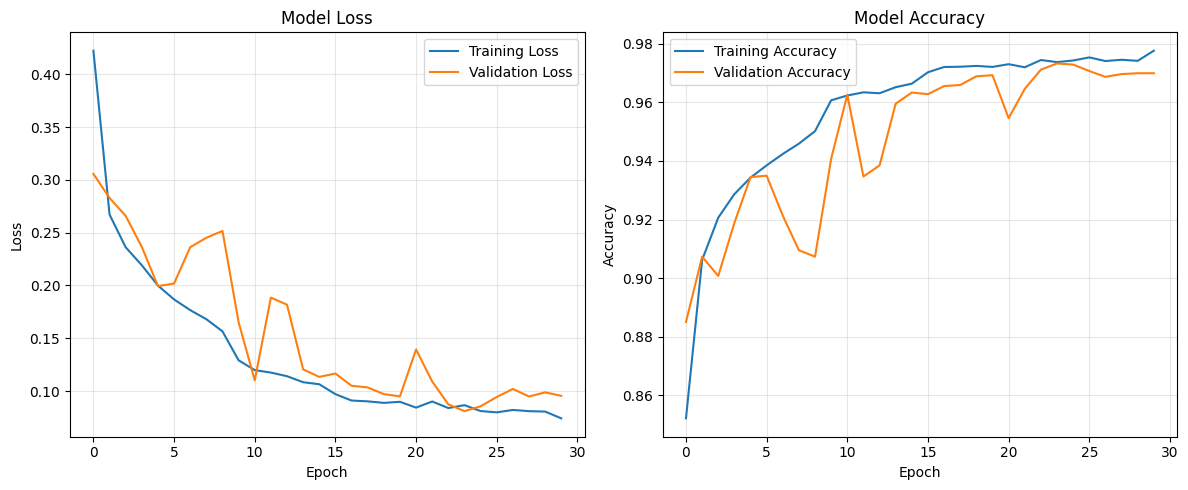

In [10]:
# 8. Plot training history
def plot_training_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Loss plot
    axes[0].plot(history.history['loss'], label='Training Loss')
    axes[0].plot(history.history['val_loss'], label='Validation Loss')
    axes[0].set_title('Model Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Accuracy plot
    axes[1].plot(history.history['accuracy'], label='Training Accuracy')
    axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
    axes[1].set_title('Model Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_training_history(history)

In [9]:
# 9. Evaluate the model
print("\n" + "="*50)
print("FINAL EVALUATION")
print("="*50)

# Training set evaluation
print("\n--- Training Set Evaluation ---")
train_eval = cnn.evaluate(training_set, verbose=0)
print(f"Training Accuracy: {train_eval[1]*100:.2f}%")
print(f"Training Loss: {train_eval[0]:.4f}")

# Validation set evaluation (from test folder)
print("\n--- Test Set Evaluation (Final) ---")
validation_set.reset()  # Reset generator
test_eval = cnn.evaluate(validation_set, verbose=1)
print(f"Test Accuracy: {test_eval[1]*100:.2f}%")
print(f"Test Loss: {test_eval[0]:.4f}")


FINAL EVALUATION

--- Training Set Evaluation ---
Training Accuracy: 98.14%
Training Loss: 0.0566

--- Test Set Evaluation (Final) ---
329/329 ━━━━━━━━━━━━━━━━━━━━ 71s 215ms/step - accuracy: 0.9689 - loss: 0.0997 - precision: 0.9697 - recall: 0.9678
Test Accuracy: 96.89%
Test Loss: 0.0997


329/329 ━━━━━━━━━━━━━━━━━━━━ 67s 202ms/step
Classes: ['Smoke', 'fire', 'non fire']

CLASSIFICATION REPORT
              precision    recall  f1-score   support

       Smoke       0.99      0.94      0.96      3500
        fire       0.98      0.98      0.98      3500
    non fire       0.94      0.99      0.96      3500

    accuracy                           0.97     10500
   macro avg       0.97      0.97      0.97     10500
weighted avg       0.97      0.97      0.97     10500



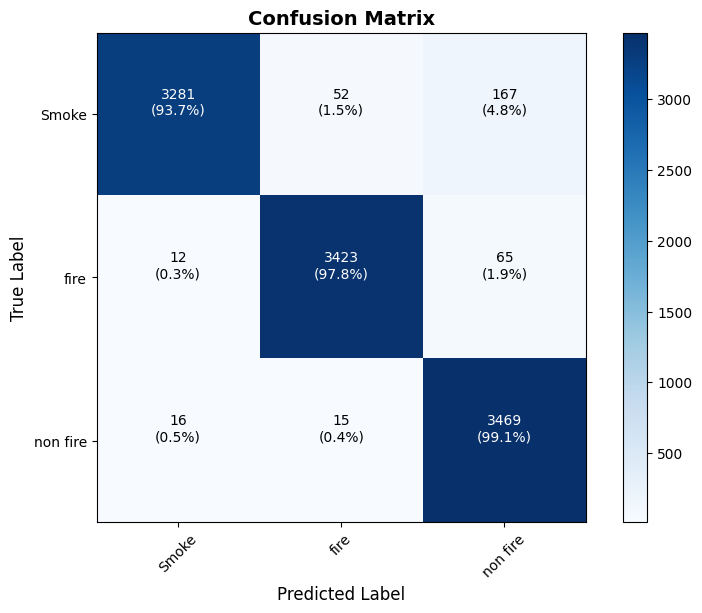

In [11]:
# 10. Generate confusion matrix and classification report
# Reset and get predictions
testing_set.reset()
predictions = cnn.predict(testing_set, verbose=1)
y_pred = np.argmax(predictions, axis=1)
y_true = testing_set.classes

# Get class names in correct order
class_names_list = [class_names[i] for i in sorted(class_names.keys())]
print(f"Classes: {class_names_list}")

# Classification report
print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_true, y_pred, target_names=class_names_list))

# Confusion matrix
def plot_confusion_matrix(cm, classes, title='Confusion Matrix', cmap=plt.cm.Blues):
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.colorbar()

    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    # Add text annotations
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, f'{cm[i, j]}\n({cm_normalized[i, j]:.1%})',
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black",
                 fontsize=10)

    plt.tight_layout()
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.show()

cm = confusion_matrix(y_true, y_pred)
plot_confusion_matrix(cm, class_names_list)


SAMPLE PREDICTIONS

Image: Fire (1009).jpg


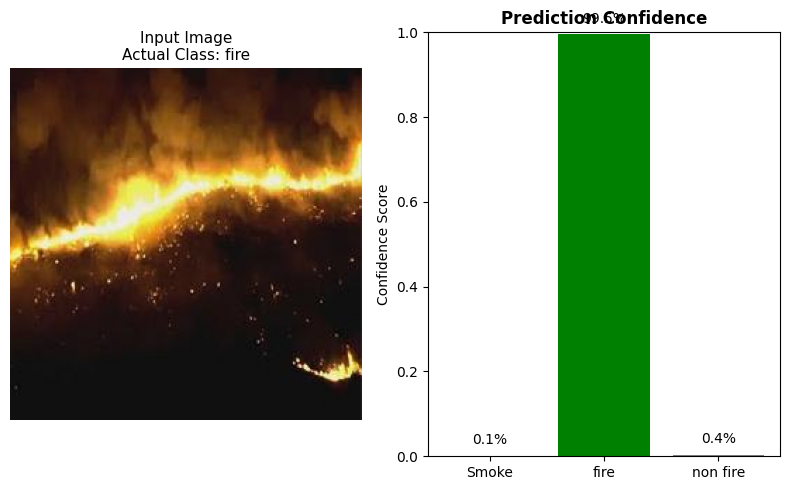


Prediction: fire
Confidence: 99.51%

Detailed probabilities:
  Smoke: 0.07%
  fire: 99.51%
  non fire: 0.42%
----------------------------------------

Image: Smoke (110).jpg


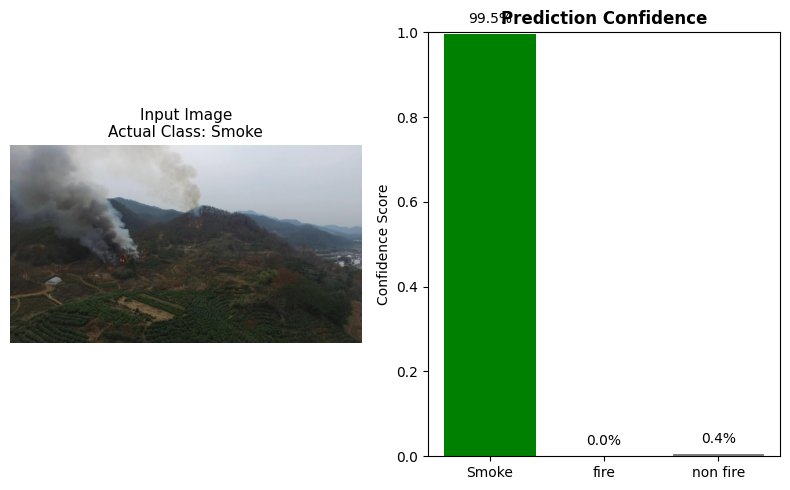


Prediction: Smoke
Confidence: 99.53%

Detailed probabilities:
  Smoke: 99.53%
  fire: 0.03%
  non fire: 0.44%
----------------------------------------

Image: NON_FIRE (179).jpg


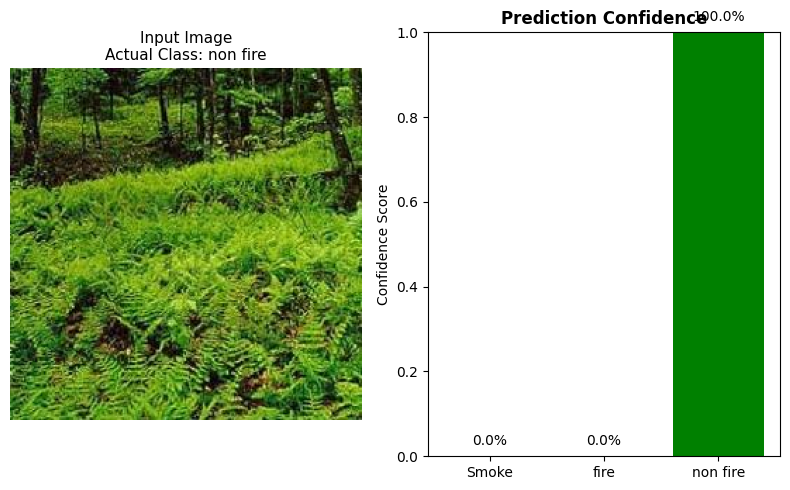


Prediction: non fire
Confidence: 99.98%

Detailed probabilities:
  Smoke: 0.01%
  fire: 0.01%
  non fire: 99.98%
----------------------------------------


In [12]:
# 11. Prediction function with confidence display
def predict_image(image_path, model, class_names_dict, img_size=IMG_SIZE):
    """
    Predict whether an image contains fire, smoke, or neither.
    """
    # Check if file exists
    if not os.path.exists(image_path):
        print(f"Error: Image not found at {image_path}")
        return None, None

    # Load and preprocess image
    img = load_img(image_path, target_size=(img_size, img_size))
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    # Make prediction
    prediction = model.predict(img_array, verbose=0)[0]
    predicted_class_idx = np.argmax(prediction)
    confidence = prediction[predicted_class_idx]

    # Get class name
    class_names_list = [class_names_dict[i] for i in sorted(class_names_dict.keys())]
    predicted_class = class_names_list[predicted_class_idx]

    # Display results
    plt.figure(figsize=(8, 5))

    # Show image
    original_img = cv2.imread(image_path)
    if original_img is not None:
        original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
        plt.subplot(1, 2, 1)
        plt.imshow(original_img)
        plt.title(f'Input Image\nActual Class: {os.path.basename(os.path.dirname(image_path))}', fontsize=11)
        plt.axis('off')

    # Show confidence bar chart
    plt.subplot(1, 2, 2)
    colors = ['green' if i == predicted_class_idx else 'gray' for i in range(len(class_names_list))]
    bars = plt.bar(class_names_list, prediction, color=colors)
    plt.title('Prediction Confidence', fontsize=12, fontweight='bold')
    plt.ylabel('Confidence Score')
    plt.ylim(0, 1)

    # Add value labels on bars
    for bar, prob in zip(bars, prediction):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{prob:.1%}', ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.show()

    print(f"\nPrediction: {predicted_class}")
    print(f"Confidence: {confidence:.2%}")
    print("\nDetailed probabilities:")
    for cls, prob in zip(class_names_list, prediction):
        print(f"  {cls}: {prob:.2%}")

    return predicted_class, confidence

# Test predictions on sample images
print("\n" + "="*50)
print("SAMPLE PREDICTIONS")
print("="*50)

test_images = [
    f'{DATA_DIR}/test/fire/Fire (1009).jpg',
    f'{DATA_DIR}/test/Smoke/Smoke (110).jpg',
    f'{DATA_DIR}/test/non fire/NON_FIRE (179).jpg'
]

for img_path in test_images:
    print(f"\nImage: {os.path.basename(img_path)}")
    predict_image(img_path, cnn, class_names)
    print("-" * 40)


Model saved to forest_fire_smoke_detection_model.h5


Model loaded successfully!


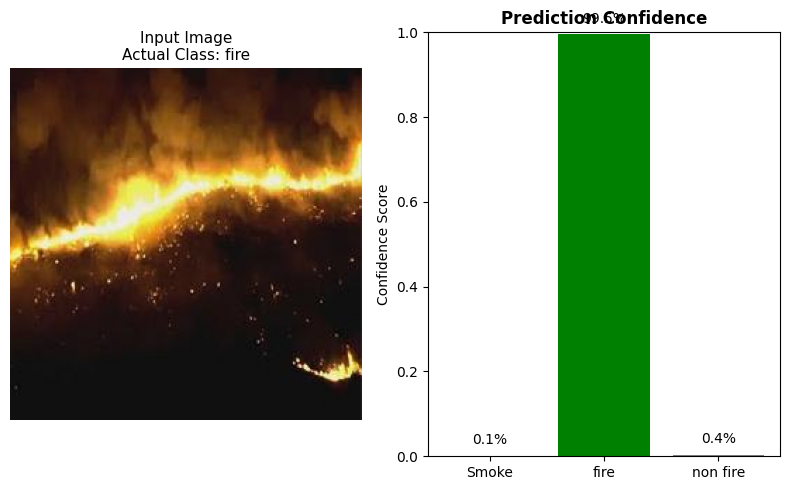


Prediction: fire
Confidence: 99.51%

Detailed probabilities:
  Smoke: 0.07%
  fire: 99.51%
  non fire: 0.42%
Model verification successful! Prediction confidence: 99.51%


In [13]:
# 12. Save the model
model_save_path = 'forest_fire_smoke_detection_model.h5'
cnn.save(model_save_path)
print(f"\nModel saved to {model_save_path}")

# Verify saved model
loaded_model = load_model(model_save_path)
print("Model loaded successfully!")

# Quick verification
test_image_path = test_images[0]
if os.path.exists(test_image_path):
    _, conf = predict_image(test_image_path, loaded_model, class_names)
    print(f"Model verification successful! Prediction confidence: {conf:.2%}")

In [14]:
cnn.save('forest_fire_smoke_detection_model.keras')